In [1]:
import os, sys
import pandas as pd
import scanpy as sc
import anndata as ad

from scipy.sparse import issparse

In [2]:
os.chdir('/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/input-data')

#### Define a function to filter based on gene expression, for labelling

In [3]:
import numpy as np
from scipy.sparse import issparse

def gene_expr_bool(adata, gene, threshold=0.0):
    """
    Return a boolean array (n_cells,) indicating which cells express `gene`
    above `threshold` in adata.X.
    If the gene is missing, returns all False.
    """
    if gene not in adata.var_names:
        print(f"Warning: {gene} not found in var_names; treating as not expressed.")
        return np.zeros(adata.n_obs, dtype=bool)
    
    sub = adata[:, gene]
    X = sub.X
    if issparse(X):
        X = X.toarray()
    X = np.ravel(X)
    return X > threshold


#### Proceed with the day 4 data, + lapatinib

In [4]:
d4_dz = sc.read_h5ad("clustered_egfDuod_D4_DZ.h5ad")

In [5]:
# Make sure leiden is string
d4_dz.obs["leiden"] = d4_dz.obs["leiden"].astype(str)

# Start with everything as PCs
d4_dz.obs["manual_label"] = "PCs"

# ISCs: cluster 0
mask_isc = d4_dz.obs["leiden"] == "0"
d4_dz.obs.loc[mask_isc, "manual_label"] = "ISCs"

# Enterocytes: cluster 2
mask_ent = d4_dz.obs["leiden"] == "2"
d4_dz.obs.loc[mask_ent, "manual_label"] = "Enterocytes"

# Inflammed Secretory PCs: cluster 4 AND REG3A/REG1B/REG1A+
reg3a_pos = gene_expr_bool(d4_dz, "REG3A")
reg1b_pos = gene_expr_bool(d4_dz, "REG1B")
reg1a_pos = gene_expr_bool(d4_dz, "REG1A")

mask_cluster4 = d4_dz.obs["leiden"] == "4"
mask_inflammed = mask_cluster4 & (reg3a_pos | reg1b_pos | reg1a_pos)
d4_dz.obs.loc[mask_inflammed, "manual_label"] = "Inflammed Secretory PCs"

# Proliferating PCs: cluster 3 AND MKI67+
mki67_pos = gene_expr_bool(d4_dz, "MKI67")
mask_cluster3 = d4_dz.obs["leiden"] == "3"
mask_prolif_pcs = mask_cluster3 & mki67_pos
d4_dz.obs.loc[mask_prolif_pcs, "manual_label"] = "Proliferating PCs"

# Quick sanity check
print(d4_dz.obs["manual_label"].value_counts())


manual_label
PCs                        23444
ISCs                       11891
Enterocytes                 7104
Proliferating PCs           1714
Inflammed Secretory PCs      228
Name: count, dtype: int64


### Inspect the participants that form our replicates

In [6]:
d4_dz.obs['participant'].unique()

['Doublet', 'H896', 'H439', 'H897', 'Negative']
Categories (5, object): ['Doublet', 'H439', 'H896', 'H897', 'Negative']

In [7]:
## Remove the doublet and negative categories

removed_participant_labels = ["Doublet", "Negative"]
d4_dz = d4_dz[
    ~d4_dz.obs['participant'].isin(removed_participant_labels),
].copy()

### Define the cell type we're analysing; Enterocytes

In [8]:
cell_type = "Enterocytes"
sub = d4_dz[d4_dz.obs["manual_label"] == cell_type].copy()
sub.obs["sample_id"] = sub.obs["participant"].astype(str)
sub.obs["pb_id"] = (
    sub.obs["sample_id"].astype(str)
    + "_"
    + sub.obs["Condition"].astype(str)
)


In [9]:
sub

AnnData object with n_obs × n_vars = 5452 × 27342
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'manual_label', 'sample_id', 'pb_id'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [10]:
### Create a pandas dataframe, of the count data

counts = sub.layers["counts"]

if issparse(counts):
    counts = counts.tocsr()

## let's confirm the shape of the counts, expecting genes as columns and cells as rows
n_cells = sub.n_obs
n_genes = sub.n_vars
print(counts.shape)
print(n_cells, n_genes)

(5452, 27342)
5452 27342


In [11]:
### Don't transpose the matrix,



In [12]:
counts.shape

(5452, 27342)

In [13]:
counts_df = pd.DataFrame.sparse.from_spmatrix(
    counts,
    index=sub.obs_names,
    columns=sub.var_names
)

counts_df

,AL627309.1,AL627309.3,AL627309.5,AL627309.4,LINC01409,LINC01128,LINC00115,FAM41C,AL645608.6,SAMD11,...,MAFIP,AC011043.1,AC011043.2,AL354822.1,AL592183.1,AC240274.1,AC004556.3,AC136352.3,AC007325.4,AC007325.2
AAACCATTCCATCCAT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCGCAACTAATG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCTGTGGAAGTC-1,0,0,0,0,0,1.0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCTGTTAAGTGG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCCTGTTGCGGTC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTACGTTGGTGCC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGTTAGTGGGTACG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGTTAGTTGCACCA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGTTGAGAACCTGC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Compute our pseudobulk values 

In [14]:
pb_counts = counts_df.groupby(sub.obs["pb_id"]).sum()


### Transpose the pandas df

In [15]:
pb_counts = pb_counts.T
pb_counts

pb_id,H439_G2D4,H896_G2D4,H897_G2D4
AL627309.1,3.0,14.0,4.0
AL627309.3,0,0,0
AL627309.5,13.0,30.0,7.0
AL627309.4,1.0,0,0
LINC01409,63.0,103.0,45.0
...,...,...,...
AC240274.1,51.0,95.0,27.0
AC004556.3,2.0,173.0,1.0
AC136352.3,1.0,3.0,2.0
AC007325.4,4.0,3.0,0


In [16]:
pb_counts.to_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/pb_counts_d4_enterocytes.csv")

### Repeat for the Lapatinib data, before merging the pseudobulk dataframes

In [17]:
del d4_dz

In [18]:
d4_lapa = sc.read_h5ad("clustered_egfDuod_D4_Lapa_DZ.h5ad")

In [19]:
# Make sure leiden is string
d4_lapa.obs["leiden"] = d4_lapa.obs["leiden"].astype(str)

# Base label for everything
d4_lapa.obs["manual_label"] = "PCs"

# Enterocytes: cluster 3
mask_ent_lapa = d4_lapa.obs["leiden"] == "3"
d4_lapa.obs.loc[mask_ent_lapa, "manual_label"] = "Enterocytes"

# Inflammed Secretory PCs / Early EECs: cluster 4
mask_inflammed_lapa = d4_lapa.obs["leiden"] == "4"
d4_lapa.obs.loc[mask_inflammed_lapa, "manual_label"] = "Inflammed secretory PCs"

# Proliferating Progenitor cells: MKI67+ anywhere (overrides other labels)
mki67_pos_lapa = gene_expr_bool(d4_lapa, "MKI67")
d4_lapa.obs.loc[mki67_pos_lapa, "manual_label"] = "Proliferating Progenitor cells"

# Sanity check
print(d4_lapa.obs["manual_label"].value_counts())


manual_label
PCs                               23328
Enterocytes                        5321
Inflammed secretory PCs            4302
Proliferating Progenitor cells     2018
Name: count, dtype: int64


In [20]:
## Remove the doublet and negative categories

removed_participant_labels = ["Doublet", "Negative"]
d4_lapa = d4_lapa[
    ~d4_lapa.obs['participant'].isin(removed_participant_labels),
].copy()

### Define the cell type we're analysing; Enterocytes

In [21]:
cell_type = "PCs"
sub = d4_lapa[d4_lapa.obs["manual_label"] == cell_type].copy()
sub.obs["sample_id"] = sub.obs["participant"].astype(str)
sub.obs["pb_id"] = (
    sub.obs["sample_id"].astype(str)
    + "_"
    + sub.obs["Condition"].astype(str)
)


In [22]:
sub

AnnData object with n_obs × n_vars = 17241 × 26742
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'manual_label', 'sample_id', 'pb_id'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [23]:
### Create a pandas dataframe, of the count data

counts = sub.layers["counts"]

if issparse(counts):
    counts = counts.tocsr()

## let's confirm the shape of the counts, expecting genes as columns and cells as rows
n_cells = sub.n_obs
n_genes = sub.n_vars
print(counts.shape)
print(n_cells, n_genes)

(17241, 26742)
17241 26742


In [24]:
### Don't transpose the matrix,



In [25]:
counts.shape

(17241, 26742)

In [26]:
counts_df = pd.DataFrame.sparse.from_spmatrix(
    counts,
    index=sub.obs_names,
    columns=sub.var_names
)

counts_df

,AL627309.1,AL627309.3,AL627309.5,LINC01409,LINC01128,LINC00115,FAM41C,AL645608.6,AL645608.2,LINC02593,...,MAFIP,AC011043.1,AC011043.2,AL354822.1,AL592183.1,AC240274.1,AC004556.3,AC136352.3,AC007325.4,AC007325.2
AAACCAAAGGTTCAAT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCAAAGTACCATG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCAAAGTAGGTCC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCAAAGTTACGCA-1,0,0,0,0,0,0,0,0,0,0,...,0,1.0,0,0,0,0,0,0,0,0
AAACCATTCCCTGATT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGTTGAGCCATACA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGTTGAGCCCTTCA-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGTTGAGCCTGCCT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGTGTTGAGGGTAGGC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Compute our pseudobulk values 

In [27]:
pb_counts = counts_df.groupby(sub.obs["pb_id"]).sum()


In [28]:
pb_counts = pb_counts.T
pb_counts

pb_id,H439_G2D4_Lapa,H896_G2D4_Lapa,H897_G2D4_Lapa
AL627309.1,14.0,27.0,10.0
AL627309.3,0,0,0
AL627309.5,36.0,80.0,25.0
LINC01409,189.0,319.0,168.0
LINC01128,85.0,143.0,101.0
...,...,...,...
AC240274.1,92.0,114.0,142.0
AC004556.3,0,31.0,4.0
AC136352.3,0,2.0,2.0
AC007325.4,6.0,6.0,6.0


### Merge the pseudobulk dfs

In [29]:
original_pb = pd.read_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/pb_counts_d4_enterocytes.csv", index_col=0)

In [30]:
original_pb

,H439_G2D4,H896_G2D4,H897_G2D4
AL627309.1,3.0,14.0,4.0
AL627309.3,0.0,0.0,0.0
AL627309.5,13.0,30.0,7.0
AL627309.4,1.0,0.0,0.0
LINC01409,63.0,103.0,45.0
...,...,...,...
AC240274.1,51.0,95.0,27.0
AC004556.3,2.0,173.0,1.0
AC136352.3,1.0,3.0,2.0
AC007325.4,4.0,3.0,0.0


In [31]:
pb_counts

pb_id,H439_G2D4_Lapa,H896_G2D4_Lapa,H897_G2D4_Lapa
AL627309.1,14.0,27.0,10.0
AL627309.3,0,0,0
AL627309.5,36.0,80.0,25.0
LINC01409,189.0,319.0,168.0
LINC01128,85.0,143.0,101.0
...,...,...,...
AC240274.1,92.0,114.0,142.0
AC004556.3,0,31.0,4.0
AC136352.3,0,2.0,2.0
AC007325.4,6.0,6.0,6.0


In [32]:
df_combined = pd.concat([original_pb, pb_counts], axis=1)


In [33]:
df_combined

,H439_G2D4,H896_G2D4,H897_G2D4,H439_G2D4_Lapa,H896_G2D4_Lapa,H897_G2D4_Lapa
AL627309.1,3.0,14.0,4.0,14.0,27.0,10.0
AL627309.3,0.0,0.0,0.0,0,0,0
AL627309.5,13.0,30.0,7.0,36.0,80.0,25.0
AL627309.4,1.0,0.0,0.0,NaN,NaN,NaN
LINC01409,63.0,103.0,45.0,189.0,319.0,168.0
...,...,...,...,...,...,...
SLITRK4,NaN,NaN,NaN,0,0,1.0
AC016925.3,NaN,NaN,NaN,0,3.0,0
BX546450.1,NaN,NaN,NaN,0,1.0,0
ATP2B3,NaN,NaN,NaN,0,2.0,0


In [34]:
df_combined.to_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/d4_df_combined_enterocytes.csv")

In [35]:
df_combined = pd.read_csv("/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-input/d4_df_combined_enterocytes.csv", index_col=0)

In [36]:
df_clean = df_combined.fillna(0)
df_clean = df_clean.astype(int)


In [37]:
counts_df = df_clean.T   # now: rows = samples, cols = genes
counts_df.shape


(6, 28120)

In [38]:
samples = counts_df.index

condition = ["Lapa" if "Lapa" in s else "Dz" for s in samples]
participant = [s.split("_")[0] for s in samples]

clinical_df = pd.DataFrame(
    {
        "condition": condition,
        "participant": participant,
    },
    index=samples,   # IMPORTANT: index must match counts_df.index
)

clinical_df


,condition,participant
H439_G2D4,Dz,H439
H896_G2D4,Dz,H896
H897_G2D4,Dz,H897
H439_G2D4_Lapa,Lapa,H439
H896_G2D4_Lapa,Lapa,H896
H897_G2D4_Lapa,Lapa,H897


### Run pydeseq2

In [39]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# create DESeq dataset
dds = DeseqDataSet(
    counts=counts_df,
    metadata=clinical_df,
    design_factors="condition",  # use the 'condition' column
)

# fit dispersions + LFCs
dds.deseq2()

# compare Lapa vs Dz
stats = DeseqStats(
    dds,
    contrast=["condition", "Lapa", "Dz"],  # tested_level, reference_level
)

stats.summary()
res = stats.results_df
res.head()


Using None as control genes, passed at DeseqDataSet initialization


/var/folders/h4/gmb18r416rs2h3sdc7knc0500000gn/T/ipykernel_1547/2528878090.py:5: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

python(1713) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(1714) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(1715) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(1716) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(1717) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(1718) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(1719) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(1720) 

Log2 fold change & Wald test p-value: condition Lapa vs Dz
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
AL627309.1    9.797365        0.447063  0.648900  0.688954  0.490852  0.625882
AL627309.3    0.000000             NaN       NaN       NaN       NaN       NaN
AL627309.5   25.018485        0.613119  0.462659  1.325206  0.185103  0.307352
AL627309.4    0.256112       -2.337045  4.411469 -0.529766  0.596274       NaN
LINC01409   124.715976        0.632981  0.323415  1.957181  0.050326  0.110739
...                ...             ...       ...       ...       ...       ...
SLITRK4       0.119875       -0.107898  4.455961 -0.024214  0.980682       NaN
AC016925.3    0.250753        0.976622  4.338370  0.225113  0.821892       NaN
BX546450.1    0.083584       -0.107898  4.455961 -0.024214  0.980682       NaN
ATP2B3        0.167169        0.481294  4.381842  0.109838  0.912538       NaN
TTTY7         0.359626        1.444224  4.308648  0.335192  0.737480    

... done in 0.46 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
AL627309.1,9.797365,0.447063,0.648900,0.688954,0.490852,0.625882
AL627309.3,0.000000,NaN,NaN,NaN,NaN,NaN
AL627309.5,25.018485,0.613119,0.462659,1.325206,0.185103,0.307352
AL627309.4,0.256112,-2.337045,4.411469,-0.529766,0.596274,NaN
LINC01409,124.715976,0.632981,0.323415,1.957181,0.050326,0.110739


### Volcano plot

/opt/anaconda3/envs/deseq-env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


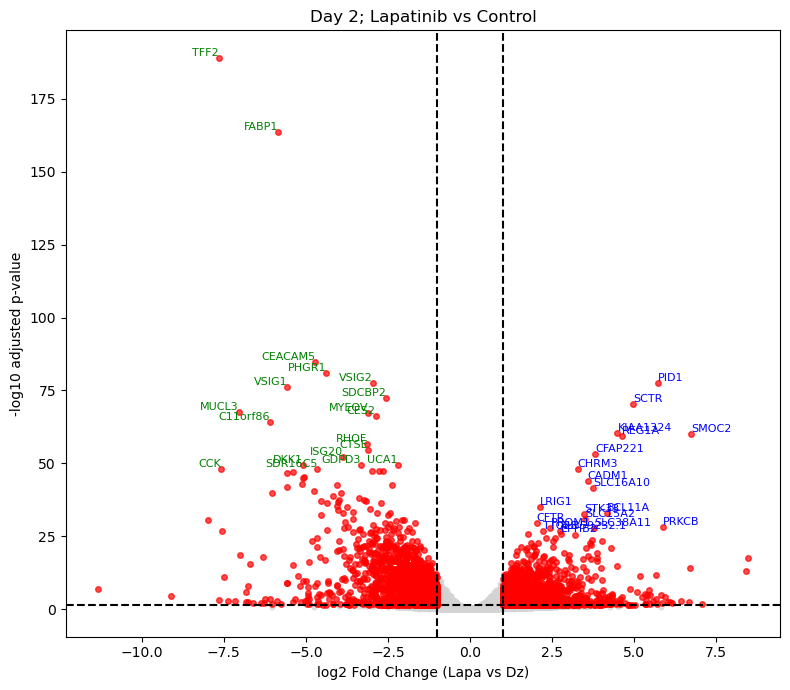

In [40]:
import numpy as np
import matplotlib.pyplot as plt

df = res.copy()
df = df.dropna(subset=["log2FoldChange", "padj"])
df["-log10padj"] = -np.log10(df["padj"])

# ----- define significance (optional) -----
sig = (df["padj"] < 0.05) & (df["log2FoldChange"].abs() > 1)

# ---- select top 20 up-regulated genes ----
top_up = (
    df[df["log2FoldChange"] > 0]
    .sort_values("padj")
    .head(20)
)

# ---- select top 20 down-regulated genes ----
top_down = (
    df[df["log2FoldChange"] < 0]
    .sort_values("padj")
    .head(20)
)

plt.figure(figsize=(8,7))

# ---- plot non-significant ----
plt.scatter(
    df.loc[~sig, "log2FoldChange"],
    df.loc[~sig, "-log10padj"],
    color="lightgray",
    alpha=0.6,
    s=12,
)

# ---- plot significant ----
plt.scatter(
    df.loc[sig, "log2FoldChange"],
    df.loc[sig, "-log10padj"],
    color="red",
    alpha=0.7,
    s=16,
)

# ---- threshold lines ----
plt.axhline(-np.log10(0.05), linestyle="--", color="black")
plt.axvline(1, linestyle="--", color="black")
plt.axvline(-1, linestyle="--", color="black")

# ---- label top up-regulated ----
for gene, row in top_up.iterrows():
    x, y = row["log2FoldChange"], row["-log10padj"]
    plt.text(
        x,
        y,
        gene,
        fontsize=8,
        color="blue",
        ha="left",
        va="bottom"
    )

# ---- label top down-regulated ----
for gene, row in top_down.iterrows():
    x, y = row["log2FoldChange"], row["-log10padj"]
    plt.text(
        x,
        y,
        gene,
        fontsize=8,
        color="green",
        ha="right",
        va="bottom"
    )

plt.xlabel("log2 Fold Change (Lapa vs Dz)")
plt.ylabel("-log10 adjusted p-value")
plt.title("Day 2; Lapatinib vs Control")
plt.tight_layout()
plt.show()


In [41]:
res.to_csv(
    "/Users/stanleydale/user_generated/Work/breault-lab/imac-single-cell/pydeseq-output/d4_enterocytes_deseq2_results.csv",
    index=True
)